## Gamma Scalping — Volatility Model Playground

This notebook is a playground for exploring different approaches to **volatility estimation and forecasting**. The goal is to build intuition for how various models behave on historical data and to compare their forecasts against realized volatility.

In [40]:
# this is ugly, but i dont know how to make it better
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from models.volatility.target import log_returns, realized_future_vol
from models.volatility.estimator import close_to_close_vol, parkinson_vol, rs_vol
from models.volatility.forecast import naive_forecast, garch_forecast

import seaborn as sns

from pathlib import Path
from datetime import datetime

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
pd.set_option('display.max_columns', None)

Given the parsed spot price data set (in this case here given hourly), we compute the hourly and/or daily close to close log-returns.

In [41]:
spot = Path('../data/parsed/spot/BTCUSDT_1h.feather')

df = pd.read_feather(spot)

df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

# Hourly log returns
r_hourly = log_returns(df, "hourly")
print("\n--- Hourly log returns ---")
print(r_hourly.head())

# Daily log returns
r_daily = log_returns(df, "daily")
print("\n--- Daily log returns ---")
print(r_daily.head())


--- Hourly log returns ---
datetime
2019-03-30 00:00:00+00:00         NaN
2019-03-30 01:00:00+00:00   -0.002372
2019-03-30 02:00:00+00:00   -0.000430
2019-03-30 03:00:00+00:00   -0.006429
2019-03-30 04:00:00+00:00   -0.002443
Name: logret_hourly, dtype: float64

--- Daily log returns ---
datetime
2019-03-30 00:00:00+00:00         NaN
2019-03-31 00:00:00+00:00   -0.000736
2019-04-01 00:00:00+00:00    0.009847
2019-04-02 00:00:00+00:00    0.158684
2019-04-03 00:00:00+00:00    0.015386
Freq: D, Name: logret_daily, dtype: float64


### Constructing Realized Volatility Targets

We consider the **forward-looking realized volatility** as the benchmark target for forecast evaluation. For each timestamp $t$, the function looks ahead to the next $h$ periods $(t+1, \dots, t+h)$, computes their realized variance, annualizes it, and aligns the result back to time $t$:

$$
RV_{t,h} \;=\; 
\sqrt{ \frac{ann}{h} \sum_{i=1}^{h} r_{t+i}^{2} } \times 100
$$

where  

- $r_{t+i}$ = log-return at step $t+i$  
- $h$ = forecast horizon (hours or days)  
- $ann$ = annualization factor (8760 for hourly, 365 for daily)

---

**Usage examples:**

```python
# Hourly horizon: next 2 hours volatility (annualized, %)
y_2h = realized_future_vol(df, h=2, freq="hourly")

# Hourly horizon: next 24 hours volatility (annualized, %)
y_24h = realized_future_vol(df, h=24, freq="hourly")

# Daily horizon: next 7 days volatility (annualized, %)
y_7d = realized_future_vol(df, h=7, freq="daily")

# Daily horizon: next 30 days volatility (annualized, %)
y_30d = realized_future_vol(df, h=30, freq="daily")



In [42]:
y_2h = realized_future_vol(df, h=2, freq="hourly")
print(y_2h.head())

y_24h = realized_future_vol(df, h=24, freq="hourly")
print(y_24h.head())

y_7d = realized_future_vol(df, h=7, freq="daily")
print(y_7d.head())

y_30d = realized_future_vol(df, h=30, freq="daily")
print(y_30d.head())

datetime
2019-03-30 00:00:00+00:00    15.956558
2019-03-30 01:00:00+00:00    42.640374
2019-03-30 02:00:00+00:00    45.515144
2019-03-30 03:00:00+00:00    36.312275
2019-03-30 04:00:00+00:00    33.407712
Name: rv_vol_future_2h_pct, dtype: float64
datetime
2019-03-30 00:00:00+00:00    22.305981
2019-03-30 01:00:00+00:00    21.842532
2019-03-30 02:00:00+00:00    22.419329
2019-03-30 03:00:00+00:00    19.494366
2019-03-30 04:00:00+00:00    18.951532
Name: rv_vol_future_24h_pct, dtype: float64
datetime
2019-03-30 00:00:00+00:00    116.621635
2019-03-31 00:00:00+00:00    117.981616
2019-04-01 00:00:00+00:00    118.129591
2019-04-02 00:00:00+00:00     31.156059
2019-04-03 00:00:00+00:00     36.399156
Freq: D, Name: rv_vol_future_7d_pct, dtype: float64
datetime
2019-03-30 00:00:00+00:00    66.300587
2019-03-31 00:00:00+00:00    66.524698
2019-04-01 00:00:00+00:00    66.560295
2019-04-02 00:00:00+00:00    37.631337
2019-04-03 00:00:00+00:00    41.081517
Freq: D, Name: rv_vol_future_30d_pct, dt

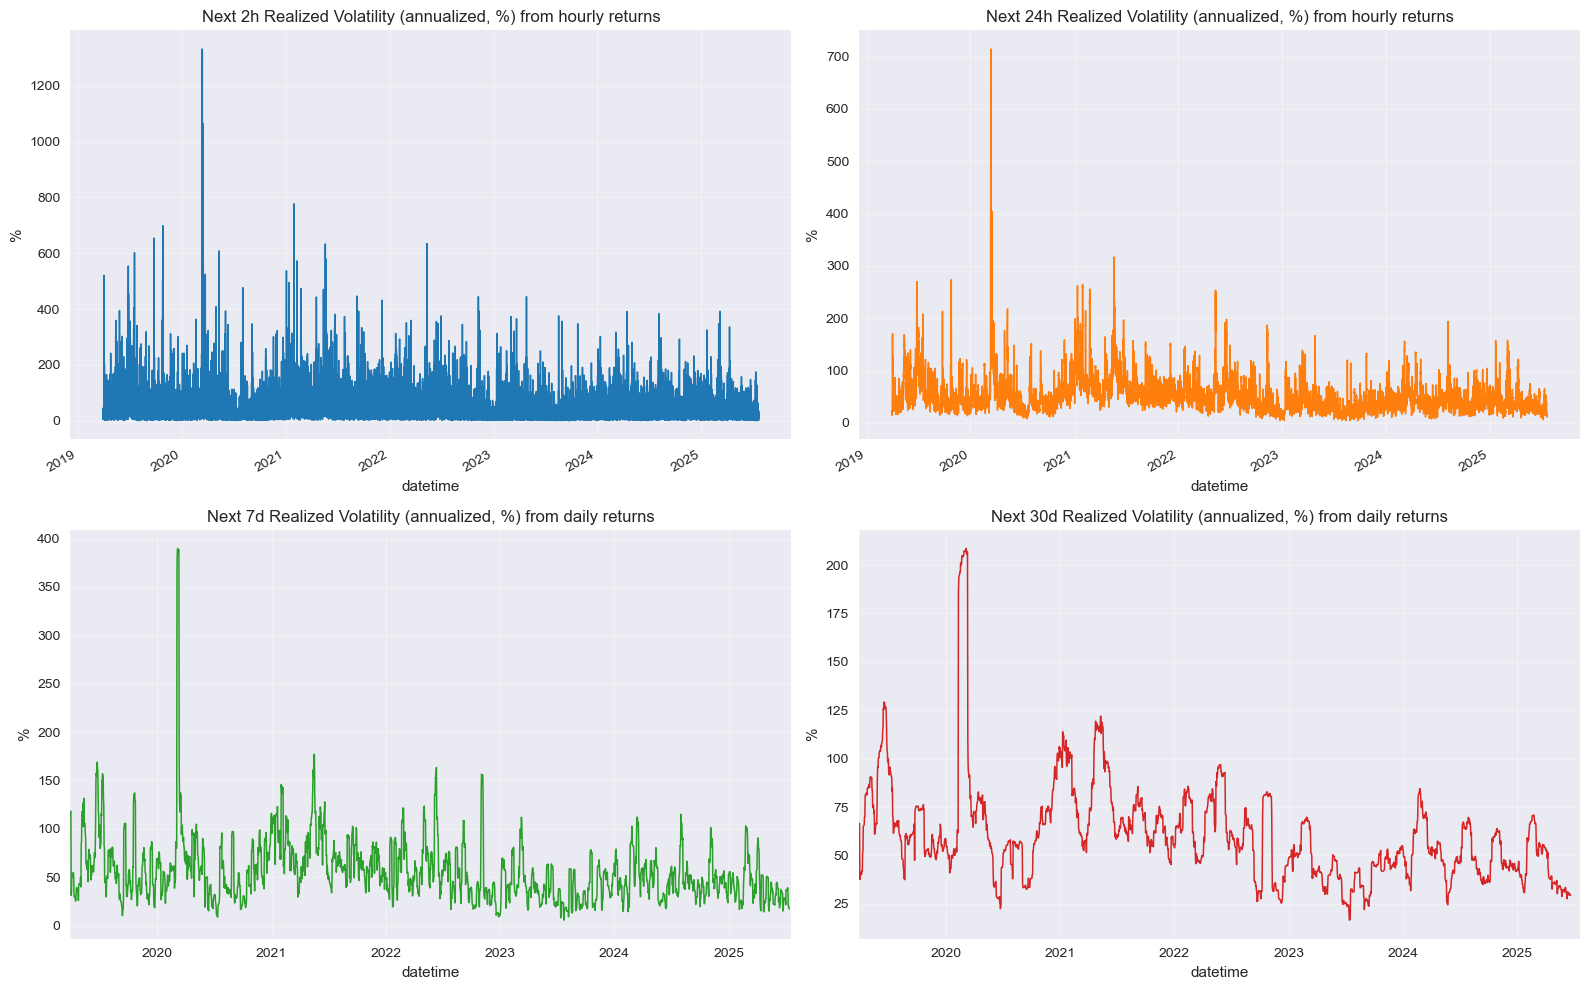

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

# --- Hourly data ---
y_2h  = realized_future_vol(df, h=2,  freq="hourly", percent=True)
y_24h = realized_future_vol(df, h=24, freq="hourly", percent=True)

y_2h.plot(ax=axes[0,0], lw=1.1, color="tab:blue")
axes[0,0].set_title("Next 2h Realized Volatility (annualized, %) from hourly returns")
axes[0,0].set_ylabel("%")

y_24h.plot(ax=axes[0,1], lw=1.1, color="tab:orange")
axes[0,1].set_title("Next 24h Realized Volatility (annualized, %) from hourly returns")
axes[0,1].set_ylabel("%")

# --- Daily data ---
y_7d  = realized_future_vol(df, h=7,  freq="daily", percent=True)
y_30d = realized_future_vol(df, h=30, freq="daily", percent=True)

y_7d.plot(ax=axes[1,0], lw=1.1, color="tab:green")
axes[1,0].set_title("Next 7d Realized Volatility (annualized, %) from daily returns")
axes[1,0].set_ylabel("%")

y_30d.plot(ax=axes[1,1], lw=1.1, color="tab:red")
axes[1,1].set_title("Next 30d Realized Volatility (annualized, %) from daily returns")
axes[1,1].set_ylabel("%")

# Format all subplots
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The plots above illustrate realized volatility at different horizons (2h, 24h, 7d, 30d). We can clearly see that:

- **Short horizons (2h, 24h)** are very noisy, with volatility frequently spiking to extreme levels (over 1000% annualized). This reflects the high sensitivity of short-term returns to sudden price moves.  
- **Medium horizons (7d)** smooth out much of the noise, but still capture occasional volatility shocks, especially around major market events.  
- **Long horizons (30d)** are the smoothest series. They reveal persistent volatility regimes (high vs. low volatility periods), and extreme short-term noise is averaged out.

Overall, realized volatility becomes less noisy and more persistent as the horizon increases. Short-term volatility is dominated by noise and jumps, while longer horizons capture structural shifts in the market.


The `close_to_close_vol()` function prepares volatility data from raw spot prices. It resamples the series to daily (or hourly) closes, computes log returns, and then estimates realized volatility using a rolling window. The result is annualized and expressed in percent, producing a clean df with prices, returns, and volatility estimates that can be used directly for forecasting and evaluation.

In [44]:
# Daily 30-day window
daily = close_to_close_vol(df, window=30, freq="daily")
display(daily.tail())

# Hourly 24-hour window
hourly = close_to_close_vol(df, window=24, freq="hourly")
display(hourly.tail())

datetime
2025-07-16 00:00:00+00:00    29.722312
2025-07-17 00:00:00+00:00    28.397649
2025-07-18 00:00:00+00:00    28.855147
2025-07-19 00:00:00+00:00    28.822057
2025-07-20 00:00:00+00:00    28.365997
Freq: D, Name: rv_est_pct, dtype: float64

datetime
2025-07-20 19:00:00+00:00    15.246579
2025-07-20 20:00:00+00:00    14.513043
2025-07-20 21:00:00+00:00    14.602468
2025-07-20 22:00:00+00:00    16.784689
2025-07-20 23:00:00+00:00    17.053145
Name: rv_est_pct, dtype: float64

The idea now is to use past data up to *t* and use it to build a volatility estimator, i.e. it tells “what the volatility has been” up to time t. We will then feed the estimator into a forecast model and then compare against the true observed realized volatility.

While close-to-close returns give us a simple starting point, they are not the most efficient way to measure volatility. In fact, much more information is available in the data: daily highs and lows capture the full trading range, and intraday returns (e.g., hourly) provide an even finer picture of realized variance.  

By incorporating these richer sources of information, we can construct better (or simply different) volatility estimators. These tend to be less noisy and more accurate than simple close-to-close measures, which could lead to better forecasts.

### Using the full OHLC Data for Volatility Estimation

Since crypto trades 24/7, we can rely on the full daily range of prices (Open, High, Low, Close) to build more efficient volatility estimators than close-to-close returns alone. Two relevant estimators in this setting are:

- Parkinson Volatility: Uses only the daily high–low range. Under continuous trading (like crypto), this estimator is highly efficient because it captures the full intraday variability without being affected by drift.

- Rogers–Satchell Volatility: Incorporates open, high, low, and close. Unlike Parkinson, it is robust to drift, making it better suited for trending markets such as BTC.

Both are expressed in annualized percent terms and provide a less noisy picture of volatility than simple close-to-close measures.

In [45]:
daily_parkinson = parkinson_vol(df, window=30, freq="daily")
display(daily_parkinson.tail())

hourly_parkinson = parkinson_vol(df, window=24, freq="hourly")
display(hourly_parkinson.tail())

datetime
2025-07-16 00:00:00+00:00    33.958816
2025-07-17 00:00:00+00:00    33.402788
2025-07-18 00:00:00+00:00    33.893990
2025-07-19 00:00:00+00:00    33.864038
2025-07-20 00:00:00+00:00    33.084297
Freq: D, Name: rv_parkinson_pct, dtype: float64

datetime
2025-07-20 19:00:00+00:00    17.558650
2025-07-20 20:00:00+00:00    17.507187
2025-07-20 21:00:00+00:00    16.929794
2025-07-20 22:00:00+00:00    22.666494
2025-07-20 23:00:00+00:00    23.338152
Freq: h, Name: rv_parkinson_pct, dtype: float64

In [46]:
daily_rs   = rs_vol(df, window=30, freq="daily")
hourly_rs  = rs_vol(df, window=24, freq="hourly")

display(daily_rs.tail())
display(hourly_rs.tail())

datetime
2025-07-16 00:00:00+00:00    35.105556
2025-07-17 00:00:00+00:00    34.755459
2025-07-18 00:00:00+00:00    35.324271
2025-07-19 00:00:00+00:00    35.275870
2025-07-20 00:00:00+00:00    34.305580
Freq: D, Name: rv_rs_pct, dtype: float64

datetime
2025-07-20 19:00:00+00:00    19.006581
2025-07-20 20:00:00+00:00    19.215264
2025-07-20 21:00:00+00:00    18.141130
2025-07-20 22:00:00+00:00    27.085093
2025-07-20 23:00:00+00:00    27.885140
Freq: h, Name: rv_rs_pct, dtype: float64

We see that all three move together and capture the same volatility regimes, but their levels differ: Close-to-Close tends to underestimate, RS is typically higher, and Parkinson sits in between. This highlights the trade-off between simplicity and information content: adding intraday data yields richer, less noisy estimates of realized volatility.

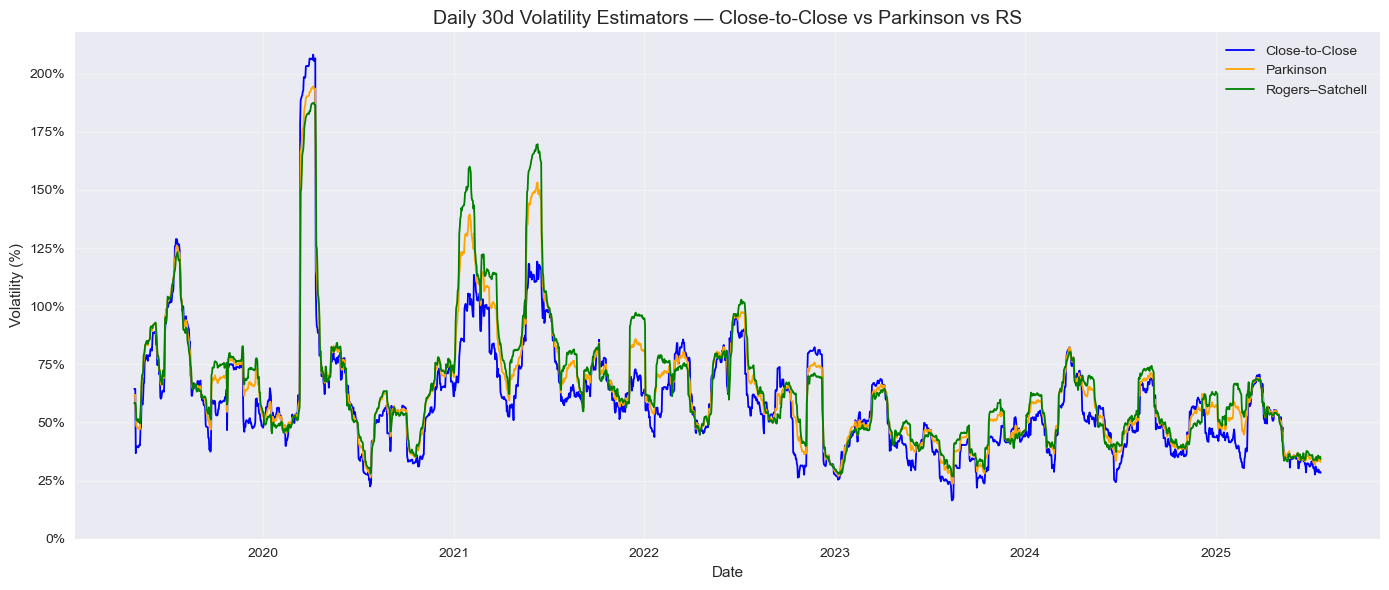

In [47]:
# Merge into one DataFrame
est_daily = pd.concat(
    [
        daily.rename("rv_est_pct"),
        daily_parkinson.rename("rv_parkinson_pct"),
        daily_rs.rename("rv_rs_pct"),
    ],
    axis=1
).dropna()

# Plot
plt.figure(figsize=(14,6))
plt.plot(est_daily.index, est_daily["rv_est_pct"], label="Close-to-Close", color="b", lw=1.3)
plt.plot(est_daily.index, est_daily["rv_parkinson_pct"], label="Parkinson", color = "orange", lw=1.3)
plt.plot(est_daily.index, est_daily["rv_rs_pct"], label="Rogers–Satchell", color = "green", lw=1.3)

plt.title("Daily 30d Volatility Estimators — Close-to-Close vs Parkinson vs RS", fontsize=14)
plt.ylabel("Volatility (%)")
plt.xlabel("Date")
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


In [48]:
# # renders in browser, unfortunately "vscode" doesn't work 
# pio.renderers.default = "browser"

# # Build a tidy frame with the three estimators (rename to your exact series vars if needed)
# est_daily = pd.concat(
#     [
#         daily.rename("rv_est_pct"),               # close-to-close (from close_to_close_vol)
#         daily_parkinson.rename("rv_parkinson_pct"),
#         daily_rs.rename("rv_rs_pct"),             # RS (from rs_vol)
#     ],
#     axis=1
# ).dropna()

# # Single-panel overlay
# fig = go.Figure()

# fig.add_trace(
#     go.Scatter(
#         x=est_daily.index, y=est_daily["rv_est_pct"],
#         mode="lines", name="Close-to-Close (rv_est_pct)",
#         line=dict(width=1.6),
#         hovertemplate="%{x|%Y-%m-%d}<br>Close-to-Close: %{y:.2f}%<extra></extra>"
#     )
# )
# fig.add_trace(
#     go.Scatter(
#         x=est_daily.index, y=est_daily["rv_parkinson_pct"],
#         mode="lines", name="Parkinson (rv_parkinson_pct)",
#         line=dict(width=1.6),
#         hovertemplate="%{x|%Y-%m-%d}<br>Parkinson: %{y:.2f}%<extra></extra>"
#     )
# )
# fig.add_trace(
#     go.Scatter(
#         x=est_daily.index, y=est_daily["rv_rs_pct"],
#         mode="lines", name="Rogers–Satchell (rv_rs_pct)",
#         line=dict(width=1.6),
#         hovertemplate="%{x|%Y-%m-%d}<br>RS: %{y:.2f}%<extra></extra>"
#     )
# )

# fig.update_layout(
#     title="Daily 30d Estimators — Close-to-Close vs Parkinson vs Rogers–Satchell",
#     template="plotly_white",
#     height=520,
#     margin=dict(l=50, r=20, t=60, b=40),
#     legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
#     yaxis_title="Volatility (%)",
#     xaxis_title="Date",
# )

# fig.show()

Next, we will introduce some forecasting methods and apply them to our estimators.

Question: How should the forecast then be outputted in order to use them in the backtest?
